In [4]:
from pathlib import Path
import time
from model.simulate import run_simulation 

VERSION = Path("Versionen/paper_draft_v1")

PASS_PROBABILITIES = [0.0, 0.1, 0.25, 0.5]

ACCESS_RULES = [
    {"name": "category_1x3", "rule": "random_categories", "category_count": 1, "cards_per_category": 3},
    {"name": "category_2x3", "rule": "random_categories", "category_count": 2, "cards_per_category": 3},
    {"name": "random_10", "rule": "random_draw", "draw_n": 10},
    {"name": "random_20", "rule": "random_draw", "draw_n": 20},
    {"name": "random_30", "rule": "random_draw", "draw_n": 30},
]

In [5]:


experiment_dir = VERSION / "results" / "rule_sensitivity"
experiment_dir.mkdir(parents=True, exist_ok=True)

results = []

start = time.perf_counter()

for access in ACCESS_RULES:
    for pass_probability in PASS_PROBABILITIES:

        experiment = f"{access['name']}_pass_{pass_probability:g}"

        print(f"\n--- {experiment} ---")

        games, plays = run_simulation(
            VERSION,
            n_games=10_000,
            rule=access["rule"],
            draw_n=access.get("draw_n", 7),
            category_count=access.get("category_count", 1),
            cards_per_category=access.get("cards_per_category", 3),
            pass_probability=pass_probability,
            seed=42,
            save=False,
            log_choices=True,
        )

        # Record experimental condition in the data itself
        games["experiment"] = experiment
        games["access_rule"] = access["name"]
        games["pass_probability"] = pass_probability

        plays["experiment"] = experiment
        plays["access_rule"] = access["name"]
        plays["pass_probability"] = pass_probability

        # Save this condition immediately
        run_dir = experiment_dir / experiment
        run_dir.mkdir(exist_ok=True)

        games.to_parquet(
            run_dir / "games.parquet",
            index=False,
        )

        plays.to_parquet(
            run_dir / "plays.parquet",
            index=False,
        )

        results.append((games, plays))


--- category_1x3_pass_0 ---
10,000/10,000 games | 3,128 games/s

--- category_1x3_pass_0.1 ---
10,000/10,000 games | 3,336 games/s

--- category_1x3_pass_0.25 ---
10,000/10,000 games | 2,207 games/s

--- category_1x3_pass_0.5 ---
10,000/10,000 games | 4,246 games/s

--- category_2x3_pass_0 ---
10,000/10,000 games | 1,735 games/s

--- category_2x3_pass_0.1 ---
10,000/10,000 games | 954 games/ss

--- category_2x3_pass_0.25 ---
10,000/10,000 games | 1,148 games/s

--- category_2x3_pass_0.5 ---
10,000/10,000 games | 1,859 games/s

--- random_10_pass_0 ---
10,000/10,000 games | 2,490 games/s

--- random_10_pass_0.1 ---
10,000/10,000 games | 3,168 games/s

--- random_10_pass_0.25 ---
10,000/10,000 games | 3,454 games/s

--- random_10_pass_0.5 ---
10,000/10,000 games | 4,947 games/s

--- random_20_pass_0 ---
10,000/10,000 games | 1,607 games/s

--- random_20_pass_0.1 ---
10,000/10,000 games | 1,544 games/s

--- random_20_pass_0.25 ---
10,000/10,000 games | 2,010 games/s

--- random_20_pass_0

In [6]:
import pandas as pd


all_games = pd.concat(
    [games for games, _ in results],
    ignore_index=True,
)

all_plays = pd.concat(
    [plays for _, plays in results],
    ignore_index=True,
)

all_games.to_parquet(
    experiment_dir / "all_games.parquet",
    index=False,
)

all_plays.to_parquet(
    experiment_dir / "all_plays.parquet",
    index=False,
)

In [7]:
summary = (
    all_games
    .groupby(["access_rule", "pass_probability"])
    .agg(
        games=("game_id", "size"),
        mean_vp=("vp", "mean"),
        median_vp=("vp", "median"),
        std_vp=("vp", "std"),
        mean_budget=("budget", "mean"),
        mean_cards=("n_cards_played", "mean"),
        completed_share=(
            "rounds_played",
            lambda x: (x == 4).mean(),
        ),
    )
    .reset_index()
)

summary


,access_rule,pass_probability,games,mean_vp,median_vp,std_vp,mean_budget,mean_cards,completed_share
0,category_1x3,0.00,10000,418.4905,419.0,237.270451,4.1642,5.6497,0.8932
1,category_1x3,0.10,10000,455.8348,467.0,240.867651,4.3362,5.0330,0.9025
2,category_1x3,0.25,10000,518.3341,564.0,242.823853,4.7719,4.0756,0.9222
3,category_1x3,0.50,10000,630.0375,724.0,230.871498,5.7391,2.4839,0.9532
4,category_2x3,0.00,10000,339.6129,298.0,224.259858,3.1066,7.7948,0.8591
5,category_2x3,0.10,10000,377.7860,359.0,229.009699,3.3490,6.9518,0.8718
6,category_2x3,0.25,10000,448.7436,454.0,238.712844,3.8262,5.5247,0.8909
7,category_2x3,0.50,10000,585.1076,658.0,239.330390,5.1240,3.1568,0.9324
8,random_10,0.00,10000,278.2555,220.0,213.697597,2.0218,9.5400,0.8218
9,random_10,0.10,10000,322.5690,274.0,225.262540,2.3881,8.3283,0.8369


In [9]:
summary.to_csv(
    experiment_dir / "summary.csv",
    index=False
    )

In [10]:
vp_table = all_games.pivot_table(
    index="pass_probability",
    columns="access_rule",
    values="vp",
    aggfunc="mean",
)

vp_table

access_rule,category_1x3,category_2x3,random_10,random_20,random_30
pass_probability,,,,,
0.00,418.4905,339.6129,278.2555,275.7556,264.9078
0.10,455.8348,377.7860,322.5690,318.0938,311.3906
0.25,518.3341,448.7436,396.4542,395.2029,394.5728
0.50,630.0375,585.1076,551.3433,550.1909,553.5134


In [11]:
cards_played_table = all_games.pivot_table(
    index="pass_probability",
    columns="access_rule",
    values="n_cards_played",
    aggfunc="mean",
)

cards_played_table

access_rule,category_1x3,category_2x3,random_10,random_20,random_30
pass_probability,,,,,
0.00,5.6497,7.7948,9.5400,10.4682,10.9051
0.10,5.0330,6.9518,8.3283,9.3125,9.7929
0.25,4.0756,5.5247,6.3803,7.0768,7.4198
0.50,2.4839,3.1568,3.4140,3.5463,3.6235


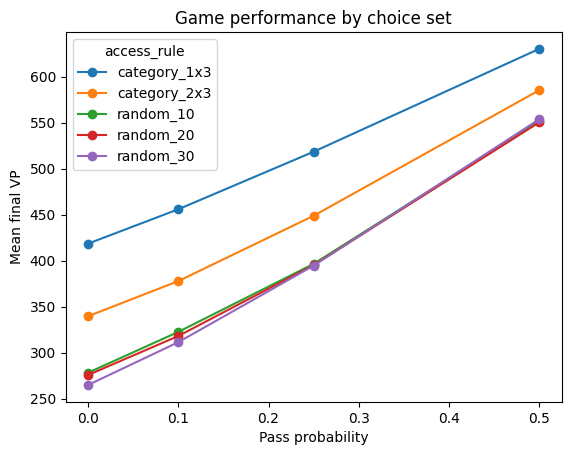

In [13]:
from matplotlib import pyplot as plt


ax = vp_table.plot(marker="o")

ax.set_xlabel("Pass probability")
ax.set_ylabel("Mean final VP")
ax.set_title("Game performance by choice set")
plt.show()

In [16]:
from model.analysis import card_analysis
from model.game import load_game_data

game_data = load_game_data(VERSION)

card_results = []

for experiment, games in all_games.groupby("experiment"):

    plays = all_plays.loc[
        all_plays["experiment"] == experiment
    ]

    result = card_analysis(
        games,
        plays=plays,
        game_data=game_data,
        elite_share=0.05,
    )

    result["experiment"] = experiment
    result["access_rule"] = games["access_rule"].iloc[0]
    result["pass_probability"] = games["pass_probability"].iloc[0]

    card_results.append(result)

card_results = pd.concat(
    card_results,
    ignore_index=True,
)

In [17]:
card_results.to_parquet(
    experiment_dir / "card_results.parquet",
    index=False,
)

In [18]:
card_robustness = (
    card_results
    .groupby(["card", "label_en"])
    .agg(
        conditions=("experiment", "nunique"),
        mean_occurrence=("occurrence", "mean"),

        mean_vp_lift=("vp_lift", "mean"),
        min_vp_lift=("vp_lift", "min"),
        max_vp_lift=("vp_lift", "max"),

        lift_estimable=("vp_lift", lambda x: x.notna().sum()),
        positive_lift_cases=("vp_lift", lambda x: (x > 0).sum()),

        mean_enrichment=("enrichment", "mean"),
        enriched_cases=("enrichment", lambda x: (x > 1).sum()),
    )
    .reset_index()
)

In [19]:
card_robustness["positive_lift_share"] = (
    card_robustness["positive_lift_cases"]
    / card_robustness["lift_estimable"]
)

card_robustness["enriched_share"] = (
    card_robustness["enriched_cases"]
    / card_robustness["conditions"]
)

card_robustness = card_robustness.sort_values(
    ["positive_lift_share", "mean_vp_lift"],
    ascending=False,
)

card_robustness

,card,label_en,conditions,mean_occurrence,mean_vp_lift,min_vp_lift,max_vp_lift,lift_estimable,positive_lift_cases,mean_enrichment,enriched_cases,positive_lift_share,enriched_share
44,shower_water_heat_recovery,Heat recovery from shower water,20,0.056145,243.912150,153.233007,406.790758,20,20,2.480522,20,1.00,1.00
46,thermal_flexibility,Thermal flexibility,20,0.146380,234.116098,160.100485,368.426015,20,20,1.969467,17,1.00,0.85
16,efficient_appliances,Efficient appliances,20,0.057515,232.765807,150.406800,350.526730,20,20,1.951883,16,1.00,0.80
27,green_gas,just use green gas!,20,0.067815,206.996517,117.037859,354.674127,20,20,6.986420,20,1.00,1.00
50,wastewater_heat_pump,Wastewater heat pumps,20,0.046075,176.450197,108.123042,295.915511,20,20,1.435053,10,1.00,0.50
28,groundwater_heat_pump,Groundwater heat pump,20,0.065810,171.620337,86.618851,299.106110,20,20,1.594677,15,1.00,0.75
13,decentralized_air_source_heat_pump,Decentralized air source heat pump,20,0.109335,165.288365,68.391264,317.817517,20,20,1.076070,6,1.00,0.30
24,geothermal_heat_pump,Geothermal heat pump,20,0.066570,159.491612,82.443048,304.484973,20,20,1.206942,8,1.00,0.40
9,central_air_source_heat_pump,Central air source heat pump,20,0.065880,158.681923,78.010782,301.168415,20,20,0.954074,6,1.00,0.30
15,district_heating_connection,District heating connection,20,0.108950,146.221487,54.693366,289.190007,20,20,1.697452,11,1.00,0.55


In [20]:
card_robustness.to_csv(
    experiment_dir / "card_robustness.csv",
    index=False,
)